<a href="https://colab.research.google.com/github/archangel2006/Quantinel/blob/main/Data%20Loading%20%26%20Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# Mount Drive

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# Column names for NSL-KDD dataset

cols = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment",
    "urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty_level"
]

# Load the official NSL-KDD train file and assign column names
train = pd.read_csv("KDDTrain+.txt", header=None, names=cols)

# Load the official NSL-KDD test file and assign column names
test = pd.read_csv("KDDTest+.txt", header=None, names=cols)

# Save cleaned versions as CSV
train.to_csv("KDDTrain_clean.csv", index=False)
test.to_csv("KDDTest_clean.csv", index=False)

print(train.shape, test.shape)

(125973, 43) (22544, 43)


In [45]:
train.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level'],
      dtype='object')

In [46]:
print(train.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [47]:
print(test.head())

   duration protocol_type   service  flag  src_bytes  dst_bytes  land  \
0         0           tcp   private   REJ          0          0     0   
1         0           tcp   private   REJ          0          0     0   
2         2           tcp  ftp_data    SF      12983          0     0   
3         0          icmp     eco_i    SF         20          0     0   
4         1           tcp    telnet  RSTO          0         15     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.04   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.61   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    0.31   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.06                         0.00   
1                    0.06                         0.00   
2       

In [48]:
df = train.copy()

# Basic structure
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (125973, 43)

Columns:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']


In [49]:
# Missing values

print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate  

In [50]:
# Duplicate rows

print("\nDuplicate rows:", df.duplicated().sum())



Duplicate rows: 0


In [51]:
# Unique values of important categorical columns

for col in ["protocol_type", "service", "flag", "label"]:
    print(f"\nUNIQUE VALUES IN {col}:")
    print(df[col].value_counts().head(20))


UNIQUE VALUES IN protocol_type:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

UNIQUE VALUES IN service:
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
eco_i         4586
other         4359
ecr_i         3077
telnet        2353
finger        1767
ftp           1754
auth           955
Z39_50         862
uucp           780
courier        734
bgp            710
whois          693
uucp_path      689
iso_tsap       687
time           654
Name: count, dtype: int64

UNIQUE VALUES IN flag:
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64

UNIQUE VALUES IN label:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back

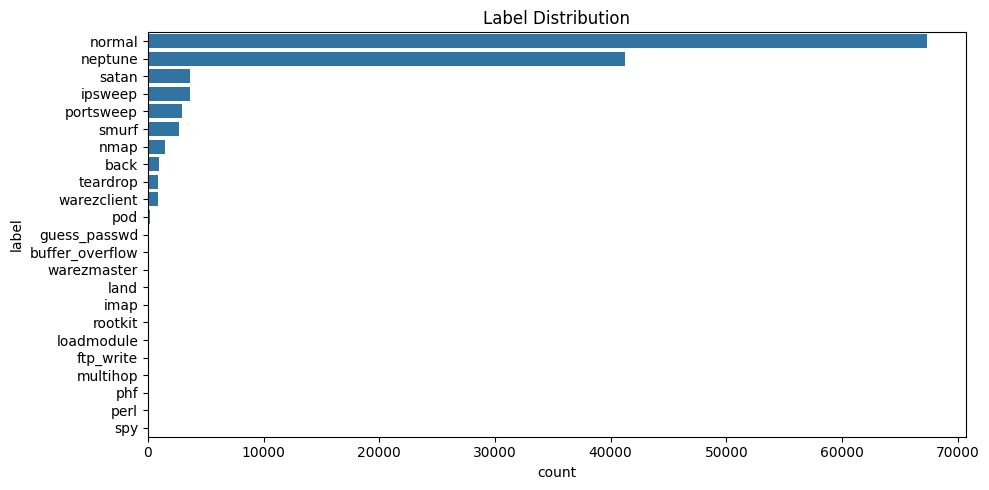

In [52]:
# Label distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="label", order=df["label"].value_counts().index)
plt.title("Label Distribution")
plt.tight_layout()
plt.show()


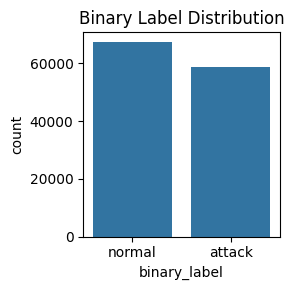

In [53]:
# Binary label view

df["binary_label"] = df["label"].apply(lambda x: "normal" if x == "normal" else "attack")
plt.figure(figsize=(3, 3))
sns.countplot(data=df, x="binary_label", order=df["binary_label"].value_counts().index)
plt.title("Binary Label Distribution")
plt.tight_layout()
plt.show()


In [54]:
# Numeric feature summary

print("\nNumeric summary:")
print(df.describe().T)


Numeric summary:
                                count          mean           std  min    25%  \
duration                     125973.0    287.144650  2.604515e+03  0.0   0.00   
src_bytes                    125973.0  45566.743000  5.870331e+06  0.0   0.00   
dst_bytes                    125973.0  19779.114421  4.021269e+06  0.0   0.00   
land                         125973.0      0.000198  1.408607e-02  0.0   0.00   
wrong_fragment               125973.0      0.022687  2.535300e-01  0.0   0.00   
urgent                       125973.0      0.000111  1.436603e-02  0.0   0.00   
hot                          125973.0      0.204409  2.149968e+00  0.0   0.00   
num_failed_logins            125973.0      0.001222  4.523914e-02  0.0   0.00   
logged_in                    125973.0      0.395736  4.890101e-01  0.0   0.00   
num_compromised              125973.0      0.279250  2.394204e+01  0.0   0.00   
root_shell                   125973.0      0.001342  3.660284e-02  0.0   0.00   
su_attempt

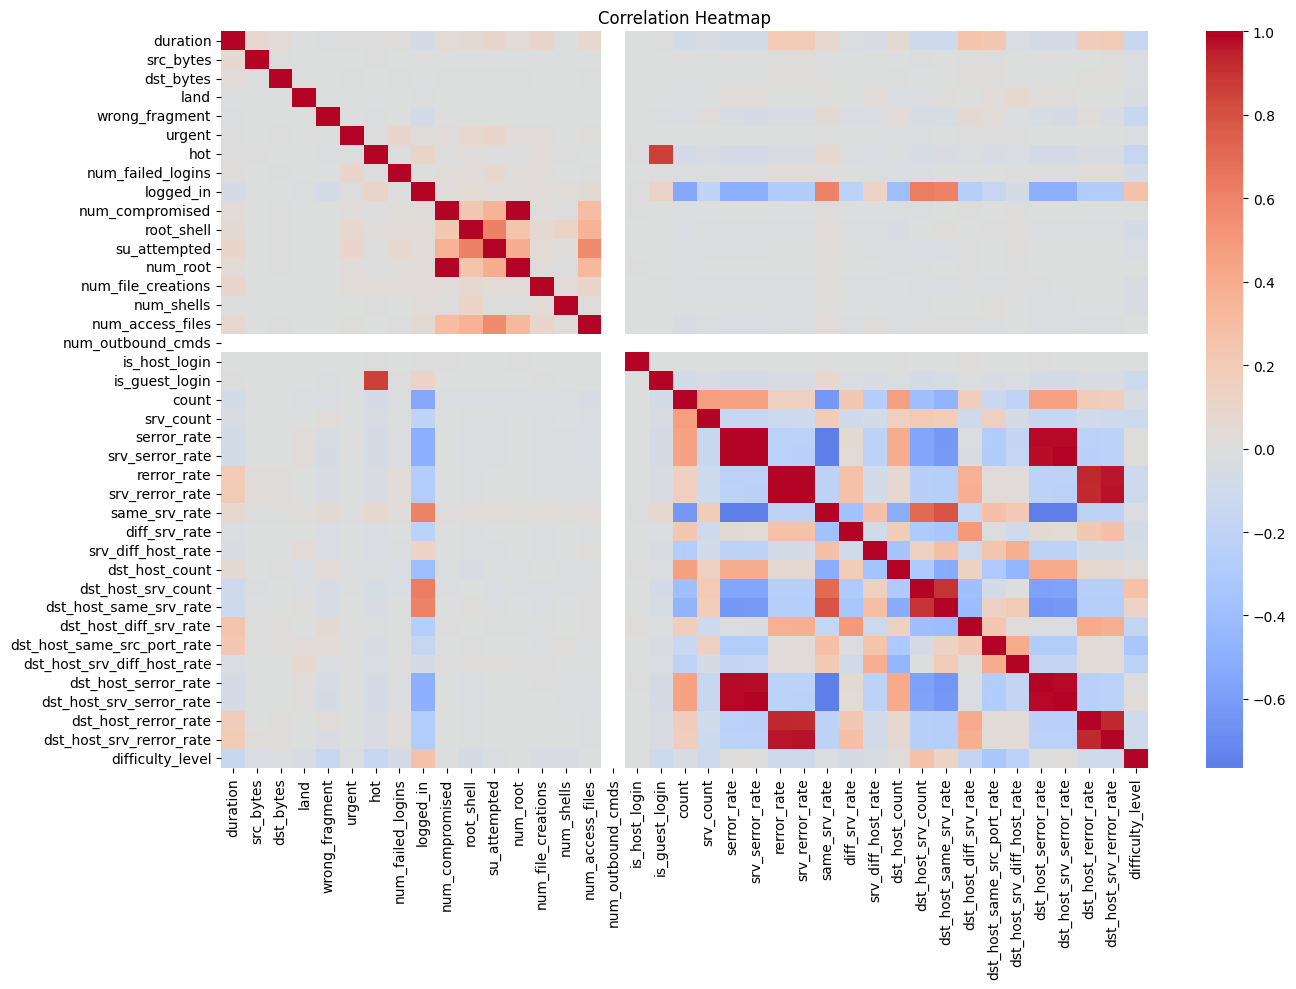

In [55]:
# Correlation heatmap for numeric columns only

num_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(14, 10))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()